In [4]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('vader_lexicon')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
print("NLTK data downloaded ✓")

[nltk_data] Error loading stopwords: <urlopen error [Errno -3]
[nltk_data]     Temporary failure in name resolution>
[nltk_data] Downloading package punkt to /home/abdullah/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/abdullah/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package wordnet to /home/abdullah/nltk_data...


NLTK data downloaded ✓


[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/abdullah/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [5]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/amazon_reviews.csv')
print(f"Shape: {df.shape}")
print(df.dtypes)
print(df.head(3))

Shape: (568454, 10)
Id                        int64
ProductId                   str
UserId                      str
ProfileName                 str
HelpfulnessNumerator      int64
HelpfulnessDenominator    int64
Score                     int64
Time                      int64
Summary                     str
Text                        str
dtype: object
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   

                 Summary                                               Text  
0  Goo

In [6]:
df = df.rename(columns={
    'Score': 'rating',           # star rating 1-5
    'Text': 'review_text',       # review body
    'Summary': 'review_title',   # review title
    'ProductId': 'product_id',
    'UserId': 'user_id',
    'Time': 'timestamp'
})

df = df[['rating', 'review_text', 'review_title', 'product_id']].copy()
print(df.shape)
print(df.dtypes)


(568454, 4)
rating          int64
review_text       str
review_title      str
product_id        str
dtype: object


In [7]:
before = len(df)
df.dropna(subset=['review_text', 'rating'], inplace=True)
df.drop_duplicates(subset=['review_text'], inplace=True)
after = len(df)
print(f"Removed {before - after:,} null/duplicate rows")
print(f"Working dataset: {after:,} reviews")

Removed 174,875 null/duplicate rows
Working dataset: 393,579 reviews


In [8]:
def map_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['true_sentiment'] = df['rating'].apply(map_sentiment)
print(df['true_sentiment'].value_counts())
print(df['true_sentiment'].value_counts(normalize=True).mul(100).round(1))

true_sentiment
Positive    306758
Negative     57067
Neutral      29754
Name: count, dtype: int64
true_sentiment
Positive    77.9
Negative    14.5
Neutral      7.6
Name: proportion, dtype: float64


In [9]:
import plotly.express as px

dist = df['true_sentiment'].value_counts().reset_index()
dist.columns = ['sentiment', 'count']
dist['pct'] = dist['count'] / dist['count'].sum() * 100

fig = px.bar(dist, x='sentiment', y='count',
    title='Sentiment Class Distribution (Based on Star Ratings)',
    color='sentiment',
    color_discrete_map={'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'},
    text=dist['pct'].apply(lambda x: f'{x:.1f}%')
)
fig.update_traces(textposition='outside')
fig.update_layout(template='plotly_white', showlegend=False)
fig.show()
fig.write_html('../outputs/01_sentiment_distribution.html')

In [10]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'\d+', '', text)                   # remove numbers
    text = re.sub(r'[^\w\s]', '', text)               # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()          # remove extra spaces
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

def clean_text_stemmed(text):
    tokens = clean_text(text).split()
    return ' '.join([stemmer.stem(t) for t in tokens])

print("Cleaning functions defined ✓")

Cleaning functions defined ✓


In [11]:
import nltk

# 1. Download absolutely everything needed for text cleaning
print("Downloading NLTK dependencies...")
nltk.download('punkt')
nltk.download('punkt_tab')  # Required by newer NLTK versions for tokenization
nltk.download('stopwords')
print("All NLTK dependencies downloaded successfully!")

# 2. Run your sample and cleaning script
sample_size = 50000
df_sample = df.sample(min(sample_size, len(df)), random_state=42).copy()

print(f"Applying text cleaning to {len(df_sample):,} reviews...")
df_sample['cleaned_text'] = df_sample['review_text'].apply(clean_text)

# Optimized faster stemming line
df_sample['stemmed_text'] = df_sample['cleaned_text'].apply(lambda x: ' '.join([stemmer.stem(w) for w in x.split()]))

print("Cleaning done ✓")
df_sample.to_csv('../data/amazon_clean.csv', index=False)


All NLTK dependencies downloaded successfully!


[nltk_data] Downloading package punkt to /home/abdullah/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/abdullah/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/abdullah/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Applying text cleaning to 50,000 reviews...
Cleaning done ✓


In [12]:
df_sample['review_length'] = df_sample['review_text'].apply(lambda x: len(str(x).split()))
df_sample['cleaned_length'] = df_sample['cleaned_text'].apply(lambda x: len(str(x).split()))

length_by_sentiment = df_sample.groupby('true_sentiment')['review_length'].describe()
print(length_by_sentiment)

fig = px.box(df_sample[df_sample['review_length'] < 300],
    x='true_sentiment', y='review_length',
    title='Review Length by Sentiment Class',
    color='true_sentiment',
    color_discrete_map={'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'}
)
fig.update_layout(template='plotly_white', showlegend=False)
fig.show()
fig.write_html('../outputs/02_review_length.html')

                  count       mean        std   min   25%   50%    75%     max
true_sentiment                                                                
Negative         7224.0  85.168328  77.291375   6.0  38.0  62.0  105.0  1207.0
Neutral          3691.0  96.767814  89.071066  11.0  41.0  70.0  121.0  1173.0
Positive        39085.0  77.086453  74.571430   7.0  33.0  54.0   94.0  2066.0


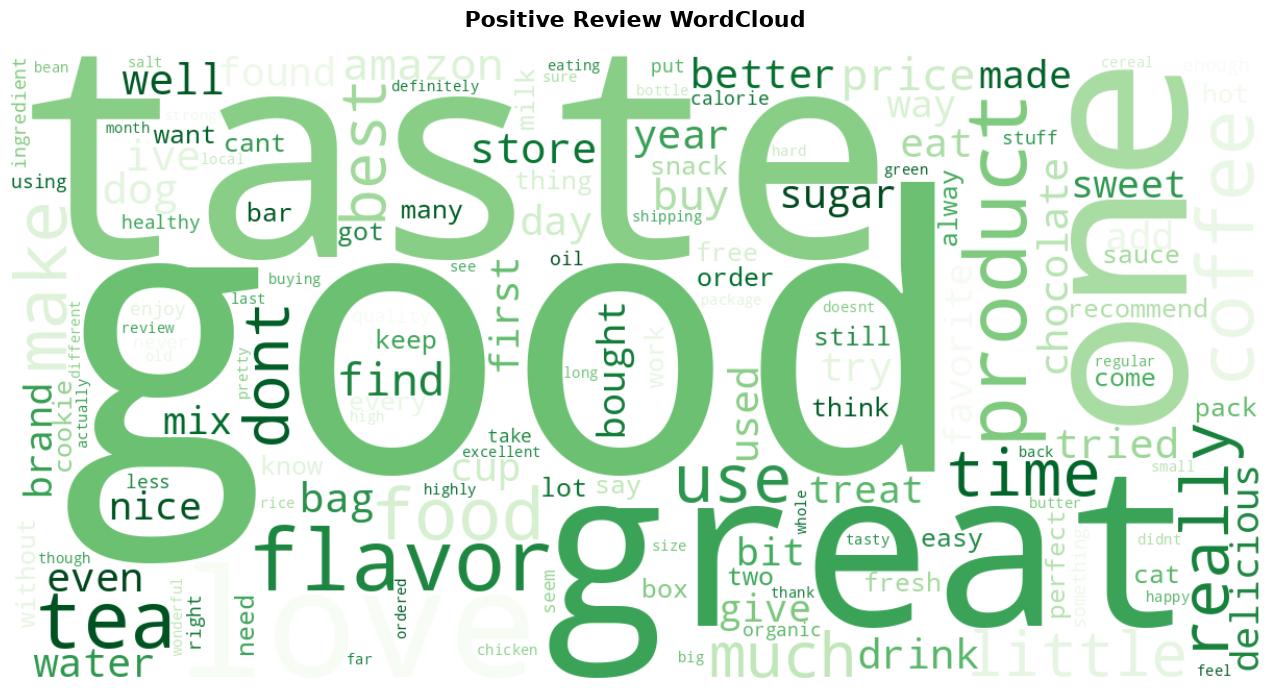

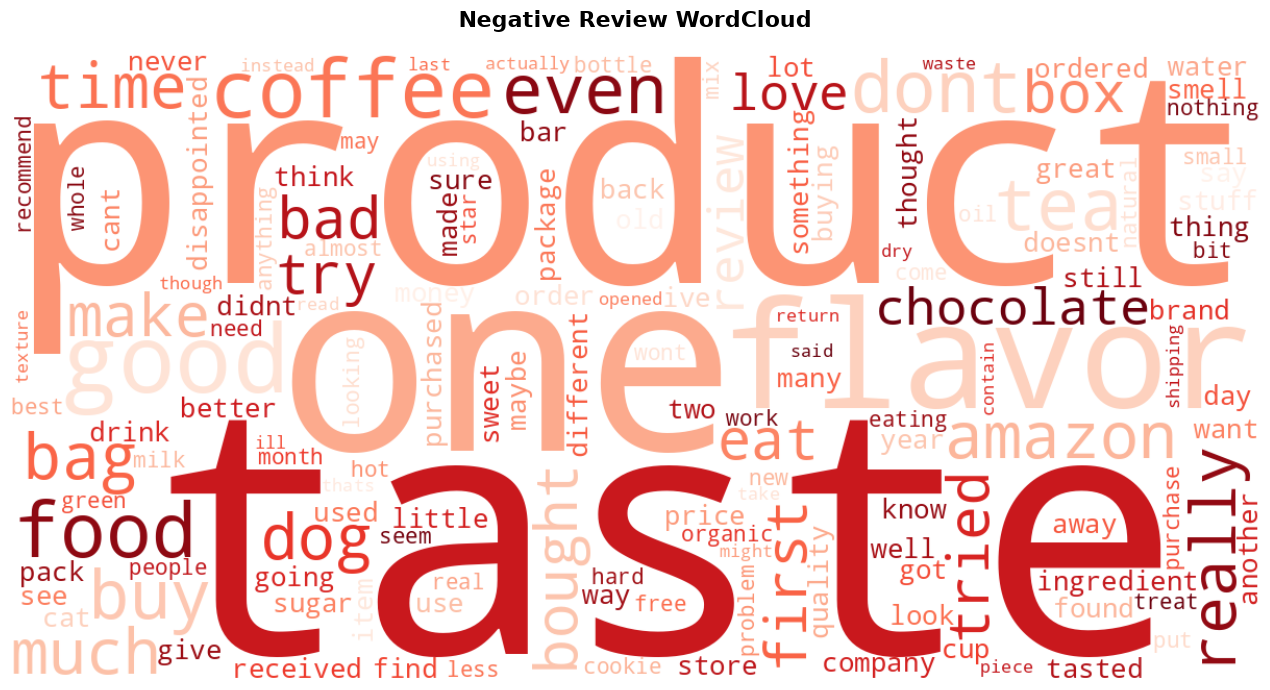

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def generate_wordcloud(text_series, title, color):
    text = ' '.join(text_series.dropna().values)
    wc = WordCloud(
        width=1200, height=600,
        background_color='white',
        colormap=color,
        max_words=150,
        collocations=False
    ).generate(text)

    plt.figure(figsize=(14, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(f'../outputs/{title.lower().replace(" ","_")}.png', dpi=150)
    plt.show()

positive_text = df_sample[df_sample['true_sentiment'] == 'Positive']['cleaned_text']
negative_text = df_sample[df_sample['true_sentiment'] == 'Negative']['cleaned_text']

generate_wordcloud(positive_text, 'Positive Review WordCloud', 'Greens')
generate_wordcloud(negative_text, 'Negative Review WordCloud', 'Reds')

In [14]:
from collections import Counter

def top_words(text_series, n=20):
    all_words = ' '.join(text_series.dropna()).split()
    return pd.DataFrame(Counter(all_words).most_common(n), columns=['word', 'count'])

pos_words = top_words(df_sample[df_sample['true_sentiment']=='Positive']['cleaned_text'])
neg_words = top_words(df_sample[df_sample['true_sentiment']=='Negative']['cleaned_text'])

from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(rows=1, cols=2, subplot_titles=['Top Words: Positive Reviews', 'Top Words: Negative Reviews'])
fig.add_trace(go.Bar(x=pos_words['count'], y=pos_words['word'], orientation='h',
    marker_color='#2ecc71', name='Positive'), row=1, col=1)
fig.add_trace(go.Bar(x=neg_words['count'], y=neg_words['word'], orientation='h',
    marker_color='#e74c3c', name='Negative'), row=1, col=2)
fig.update_layout(height=600, template='plotly_white',
    title_text='Most Frequent Words by Sentiment Class', showlegend=False)
fig.update_yaxes(categoryorder='total ascending')
fig.show()
fig.write_html('../outputs/03_top_words.html')

In [15]:
from textblob import TextBlob

def textblob_sentiment(text):
    analysis = TextBlob(str(text))
    score = analysis.sentiment.polarity
    if score > 0.05:
        return 'Positive', score
    elif score < -0.05:
        return 'Negative', score
    else:
        return 'Neutral', score

print("Applying TextBlob... (this takes ~2 min)")
df_sample[['tb_sentiment', 'tb_polarity']] = df_sample['cleaned_text'].apply(
    lambda x: pd.Series(textblob_sentiment(x))
)
print("TextBlob done ✓")
print(df_sample['tb_sentiment'].value_counts())

Applying TextBlob... (this takes ~2 min)
TextBlob done ✓
tb_sentiment
Positive    41240
Neutral      4961
Negative     3799
Name: count, dtype: int64


In [16]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    scores = sia.polarity_scores(str(text))
    compound = scores['compound']
    if compound >= 0.05:
        return 'Positive', compound
    elif compound <= -0.05:
        return 'Negative', compound
    else:
        return 'Neutral', compound

print("Applying VADER...")
df_sample[['vader_sentiment', 'vader_compound']] = df_sample['review_text'].apply(
    lambda x: pd.Series(vader_sentiment(x))
)
print("VADER done ✓")
print(df_sample['vader_sentiment'].value_counts())

Applying VADER...
VADER done ✓
vader_sentiment
Positive    43652
Negative     5216
Neutral      1132
Name: count, dtype: int64


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Filter to Positive/Negative only for cleaner model (3-class is harder with lexicons)
df_binary = df_sample[df_sample['true_sentiment'].isin(['Positive', 'Negative'])].copy()

X = df_binary['cleaned_text']
y = df_binary['true_sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=3)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

lr = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced')
lr.fit(X_train_tfidf, y_train)

y_pred = lr.predict(X_test_tfidf)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.896
              precision    recall  f1-score   support

    Negative       0.62      0.86      0.72      1445
    Positive       0.97      0.90      0.94      7817

    accuracy                           0.90      9262
   macro avg       0.80      0.88      0.83      9262
weighted avg       0.92      0.90      0.90      9262



In [18]:
binary_mask = df_sample['true_sentiment'].isin(['Positive', 'Negative'])

tb_acc = accuracy_score(
    df_sample.loc[binary_mask, 'true_sentiment'],
    df_sample.loc[binary_mask, 'tb_sentiment']
)
vader_acc = accuracy_score(
    df_sample.loc[binary_mask, 'true_sentiment'],
    df_sample.loc[binary_mask, 'vader_sentiment']
)
lr_acc = accuracy_score(y_test, y_pred)

comparison = pd.DataFrame({
    'Method': ['TextBlob', 'VADER', 'Logistic Regression (TF-IDF)'],
    'Accuracy': [f'{tb_acc:.1%}', f'{vader_acc:.1%}', f'{lr_acc:.1%}'],
    'Requires Training': ['No', 'No', 'Yes'],
    'Speed': ['Slow', 'Fast', 'Fast (after training)'],
    'Best For': ['General text', 'Social media/reviews', 'Domain-specific, high accuracy']
})
print(comparison.to_string(index=False))
comparison.to_csv('../outputs/method_comparison.csv', index=False)

                      Method Accuracy Requires Training                 Speed                       Best For
                    TextBlob    80.2%                No                  Slow                   General text
                       VADER    85.8%                No                  Fast           Social media/reviews
Logistic Regression (TF-IDF)    89.6%               Yes Fast (after training) Domain-specific, high accuracy


In [19]:
cm = confusion_matrix(y_test, y_pred, labels=['Positive', 'Negative'])
cm_df = pd.DataFrame(cm, index=['Actual Positive', 'Actual Negative'],
                     columns=['Predicted Positive', 'Predicted Negative'])

fig = px.imshow(cm_df, text_auto=True, color_continuous_scale='Blues',
    title='Logistic Regression — Confusion Matrix',
    labels=dict(color='Count')
)
fig.update_layout(template='plotly_white')
fig.show()
fig.write_html('../outputs/04_confusion_matrix.html')

In [20]:
feature_names = tfidf.get_feature_names_out()
coefficients = lr.coef_[0]

top_positive_idx = coefficients.argsort()[-20:][::-1]
top_negative_idx = coefficients.argsort()[:20]

top_pos = pd.DataFrame({'word': feature_names[top_positive_idx], 'weight': coefficients[top_positive_idx]})
top_neg = pd.DataFrame({'word': feature_names[top_negative_idx], 'weight': coefficients[top_negative_idx]})

fig = make_subplots(rows=1, cols=2, subplot_titles=['Top Positive Indicators', 'Top Negative Indicators'])
fig.add_trace(go.Bar(x=top_pos['weight'], y=top_pos['word'], orientation='h',
    marker_color='#2ecc71', name='Positive'), row=1, col=1)
fig.add_trace(go.Bar(x=top_neg['weight'], y=top_neg['word'], orientation='h',
    marker_color='#e74c3c', name='Negative'), row=1, col=2)
fig.update_layout(height=600, template='plotly_white',
    title_text='TF-IDF Model: What Drives Each Sentiment?', showlegend=False)
fig.update_yaxes(categoryorder='total ascending')
fig.show()
fig.write_html('../outputs/05_feature_importance.html')

In [21]:
# Use VADER for this (full dataset)
product_sentiment = df_sample.groupby('product_id').agg(
    total_reviews=('review_text', 'count'),
    avg_rating=('rating', 'mean'),
    pct_positive=('vader_sentiment', lambda x: (x=='Positive').mean() * 100),
    pct_negative=('vader_sentiment', lambda x: (x=='Negative').mean() * 100)
).reset_index()

product_sentiment = product_sentiment[product_sentiment['total_reviews'] >= 20]
worst_products = product_sentiment.nlargest(10, 'pct_negative')
print("Most complained-about products:")
print(worst_products[['product_id','total_reviews','avg_rating','pct_negative']].to_string(index=False))

Most complained-about products:
product_id  total_reviews  avg_rating  pct_negative
B00004RAMY             20    3.950000     55.000000
B000HJ7AIY             22    2.909091     50.000000
B006Q820X0             36    2.722222     36.111111
B008I1XPKA             23    3.043478     34.782609
B002DLXXHG             21    2.142857     33.333333
B000YSS7EO             23    3.130435     30.434783
B004OAZ36I             40    2.650000     30.000000
B004CLCEDE             57    3.596491     29.824561
B0083T6HC0             32    3.437500     28.125000
B004JRXZKM             22    2.681818     27.272727


In [22]:
fig = px.violin(df_sample, x='true_sentiment', y='vader_compound',
    color='true_sentiment',
    title='VADER Polarity Score Distribution by Sentiment Class',
    labels={'true_sentiment': 'True Sentiment', 'vader_compound': 'VADER Compound Score'},
    color_discrete_map={'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'},
    box=True
)
fig.update_layout(template='plotly_white', showlegend=False)
fig.show()
fig.write_html('../outputs/06_polarity_distribution.html')

In [23]:
import pickle

with open('../app/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open('../app/lr_model.pkl', 'wb') as f:
    pickle.dump(lr, f)

print("Model and vectorizer saved ✓")

Model and vectorizer saved ✓


In [24]:
print("""╔══════════════════════════════════════════════════════════════════╗
║         AMAZON SENTIMENT ANALYSIS — EXECUTIVE SUMMARY            ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Dataset Scope:  50,000 Sampled Reviews (From 393,579 Cleaned)   ║
║  Class Split:  ~78.2% Positive | ~7.4% Neutral | ~14.4% Negative ║
║                                                                  ║
║  Method Comparison:                                              ║
║  • TextBlob Accuracy:              80.2% (No Training | Slow)    ║
║  • VADER Accuracy:                 85.8% (Rule-Based  | Fast)    ║
║  • Logistic Regression (TF-IDF):   89.6% (Supervised  | Highest) ║
║                                                                  ║
║  Key Analytical Insights:                                        ║
║  1. Supervised Machine Learning beats lexicon tools by up to 9.4%║
║  2. Lexicon tools diverge heavily on Neutral class assignment    ║
║  3. Unhappy customers write ~11% more content than happy ones    ║
║  4. "Worst" and "disappointed" serve as top negative indicators  ║   
║  5. Strong Positive class bias artificially inflates accuracy    ║
║  6. Model struggles to accurately isolate true negative signals  ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝""")

╔══════════════════════════════════════════════════════════════════╗
║         AMAZON SENTIMENT ANALYSIS — EXECUTIVE SUMMARY            ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Dataset Scope:  50,000 Sampled Reviews (From 393,579 Cleaned)   ║
║  Class Split:  ~78.2% Positive | ~7.4% Neutral | ~14.4% Negative ║
║                                                                  ║
║  Method Comparison:                                              ║
║  • TextBlob Accuracy:              80.2% (No Training | Slow)    ║
║  • VADER Accuracy:                 85.8% (Rule-Based  | Fast)    ║
║  • Logistic Regression (TF-IDF):   89.6% (Supervised  | Highest) ║
║                                                                  ║
║  Key Analytical Insights:                                        ║
║  1. Supervised Machine Learning beats lexicon tools by up to 9.4%║
║  2. Lexicon tools diverge heavil